# Persistence Model

The persistence baseline predicts that the next CPU value equals the previous observed value.

In [6]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT / "src"))

from forecast_utils import *
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv(DATA_DIR / 'persistence_data.csv', parse_dates=['timestamp'])
train, test = train_test_split_time(df)
print(train.shape, test.shape)

(7142, 2) (1786, 2)


In [7]:
pred = test['cpu_utilization'].shift(1).fillna(train['cpu_utilization'].iloc[-1])
mse = mean_squared_error(test['cpu_utilization'], pred)
metrics = {
    'MAE': mean_absolute_error(test['cpu_utilization'], pred),
    'MSE': mse,
    'RMSE': np.sqrt(mse),
    'R2': r2_score(test['cpu_utilization'], pred),
}
metrics

{'MAE': 0.004350827172615198,
 'MSE': 0.0001486171848305527,
 'RMSE': np.float64(0.012190864810609324),
 'R2': 0.03417222391881258}

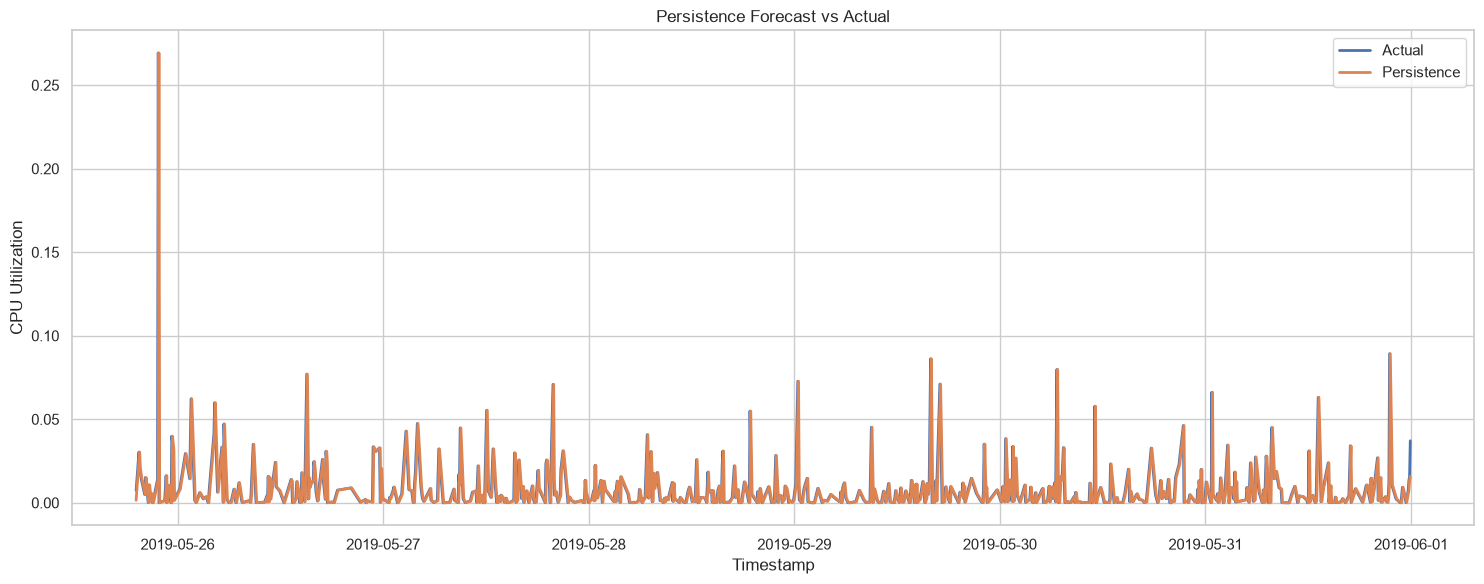

,timestamp,actual,persistence
7142,2019-05-25 19:10:00,0.007260,0.001484
7143,2019-05-25 19:15:00,0.013036,0.007260
7144,2019-05-25 19:20:00,0.018813,0.013036
7145,2019-05-25 19:25:00,0.024589,0.018813
7146,2019-05-25 19:30:00,0.030365,0.024589


In [8]:
path, pred_df = save_prediction_csv('persistence', test['timestamp'], test['cpu_utilization'], pred)
plot_actual_predicted(pred_df, 'persistence', 'Persistence Forecast vs Actual', 'persistence_forecast.png')
pred_df.head()